In [ ]:
import openai
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import  WikipediaAPIWrapper


In [4]:
# Wikipedia Tool
wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
tool = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)


In [14]:
from langchain.chat_models import init_chat_model
llm = init_chat_model('groq:qwen/qwen3-32b')

In [5]:
class AgentState (TypedDict):
    messages : Annotated[list[AnyMessage],operator.add]

In [33]:
class Agent:
    def __init__(self,model,tools,system= ""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm",self.llm_call)
        graph.add_node("action",self.take_action)
        graph.add_conditional_edges("llm",self.exists_action,{
            True:"action",
            False: END
        })
        graph.add_edge("llm","action")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name for t in tools}
        self.model = model.bind_tools(tools)
    
    def llm_call(self,state:AgentState):
        message = state["messages"]
        if self.system:
            message = [SystemMessage(content=self.system)] + message
        response = self.model.invoke(message)
        return {"messages":[response]}
        
    def take_action(self,state:AgentState):
        tools = state["messages"][-1].tool_calls
        results = []
        for t in tools:
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(content=result,tool_call_id=t["id"],name=t["name"]))
        return {'messages':results}
    
    def exists_action(self,state:AgentState):
        messages = state["messages"][-1]
        return len(messages.tool_calls) > 0



In [34]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

agent = Agent(llm,[tool],prompt)

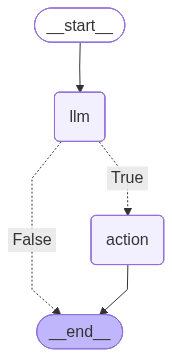

In [35]:
agent.graph

In [36]:
messages = [HumanMessage(content="Whats your name?")]
agent.graph.invoke({"messages":messages})

{'messages': [HumanMessage(content='Whats your name?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='My name is Qwen. I am a large-scale language model developed by Tongyi Lab. How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "Whats your name?" Let me think about how to respond.\n\nFirst, I need to remember that I\'m Qwen, the language model developed by Tongyi Lab. But the user might not know that. They want to know my name. The correct answer is to state my name clearly. \n\nWait, do I need to use any tools here? The tools provided include a Wikipedia function. But the question is straightforward and doesn\'t require looking up information. My name is a basic fact that I should know without needing to search. So no need to call any functions here. Just respond directly with my name. \n\nMake sure the response is friendly and concise. Let me check if there\'s any other info needed, but the user just wants the name. So

In [38]:
messages = [HumanMessage(content="Hi Quen. Where do you stay?")]
response = agent.graph.invoke({"messages":messages})

In [41]:
response["messages"][-1]

AIMessage(content="I don't have a physical location since I'm an AI language model, but I'm hosted online and can be accessed from anywhere in the world. My developers at Alibaba Cloud are based in Hangzhou, China. Is there something specific you'd like to know?", additional_kwargs={'reasoning_content': 'Okay, the user asked, "Hi Quen. Where do you stay?" First, I need to understand what they\'re asking. Since I\'m an AI, I don\'t have a physical location. But maybe they want to know where my servers are located or where the company that created me is based.\n\nI should check if there\'s any official information about the company\'s headquarters. The user might be referring to Quen, which could be a name they gave me, but I\'m not sure. Let me think—maybe they meant "Quen" as a name, but I\'m actually Qwen. Maybe a typo. Anyway, focusing on the question: where do I "stay"? Since I\'m an AI, I don\'t have a physical presence. But the company behind me, Tongyi Lab, is part of Alibaba Gro